## Machine Learning - Wine Quality Prediction

**Developer:** Ayansewa Adedeji

Course: Artificial Intelligence Applications

Program Requirements:
1. Get
2. Clean
3. Prepare
4. Analyze
5. Visualize
6. Identify correlations
7. Create classifications ("Good" or "Bad"
8. Make predictions (i.e., "quality score")

In [1]:
# 1. Import necessary modules
import sys
import os
import pandas as pd
import sklearn

#Analysis
sklearn.model_selection
sklearn.preprocessing
sklearn.ensemble
sklearn.metrics

#plots
import matplotlib.pyplot as plt
import seaborn as sns
print (sys.version)
print (os.environ['CONDA_DEFAULT_ENV'])

3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
testenv


In [2]:
# 2. Get wine quality data
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

In [3]:
#3. Read csv file into DataFrame
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv")

In [4]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')

### Display DataFrame characteristics

In [5]:
# print number of rows and columns
print(df.shape)

(1599, 12)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
#print dataframe statistics summary (format entire dataframe to two decimal places w/thousand separator
df.describe().style.format("{:,.2f}")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,"1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00"
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [8]:
# 7. Print DataFrame attributes: index, columns, size, and shape
print("Index:", df.index)
print("Columns:", df.columns)

print("\nShape:", df.shape)
print("Size (rows x cols):", df.size)

Index: RangeIndex(start=0, stop=1599, step=1)
Columns: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Shape: (1599, 12)
Size (rows x cols): 19188


In [9]:
# 8. Display first and last five rows with one command!
pd.concat([df.head(), df.tail()]).style.format("{:.2f}")
df.round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.00,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.10,25.0,67.0,1.00,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.09,15.0,54.0,1.00,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.08,17.0,60.0,1.00,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.00,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.60,0.08,2.0,0.09,32.0,44.0,0.99,3.45,0.58,10.5,5
1595,5.9,0.55,0.10,2.2,0.06,39.0,51.0,1.00,3.52,0.76,11.2,6
1596,6.3,0.51,0.13,2.3,0.08,29.0,40.0,1.00,3.42,0.75,11.0,6
1597,5.9,0.64,0.12,2.0,0.08,32.0,44.0,1.00,3.57,0.71,10.2,5


In [10]:
# 9. Display correlation matrix (Table)

df.corr().style.format("{:.2f}")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.00,-0.26,0.67,0.11,0.09,-0.15,-0.11,0.67,-0.68,0.18,-0.06,0.12
volatile acidity,-0.26,1.00,-0.55,0.00,0.06,-0.01,0.08,0.02,0.23,-0.26,-0.20,-0.39
citric acid,0.67,-0.55,1.00,0.14,0.20,-0.06,0.04,0.36,-0.54,0.31,0.11,0.23
residual sugar,0.11,0.00,0.14,1.00,0.06,0.19,0.20,0.36,-0.09,0.01,0.04,0.01
chlorides,0.09,0.06,0.20,0.06,1.00,0.01,0.05,0.20,-0.27,0.37,-0.22,-0.13
free sulfur dioxide,-0.15,-0.01,-0.06,0.19,0.01,1.00,0.67,-0.02,0.07,0.05,-0.07,-0.05
total sulfur dioxide,-0.11,0.08,0.04,0.20,0.05,0.67,1.00,0.07,-0.07,0.04,-0.21,-0.19
density,0.67,0.02,0.36,0.36,0.20,-0.02,0.07,1.00,-0.34,0.15,-0.50,-0.17
pH,-0.68,0.23,-0.54,-0.09,-0.27,0.07,-0.07,-0.34,1.00,-0.20,0.21,-0.06
sulphates,0.18,-0.26,0.31,0.01,0.37,0.05,0.04,0.15,-0.20,1.00,0.09,0.25


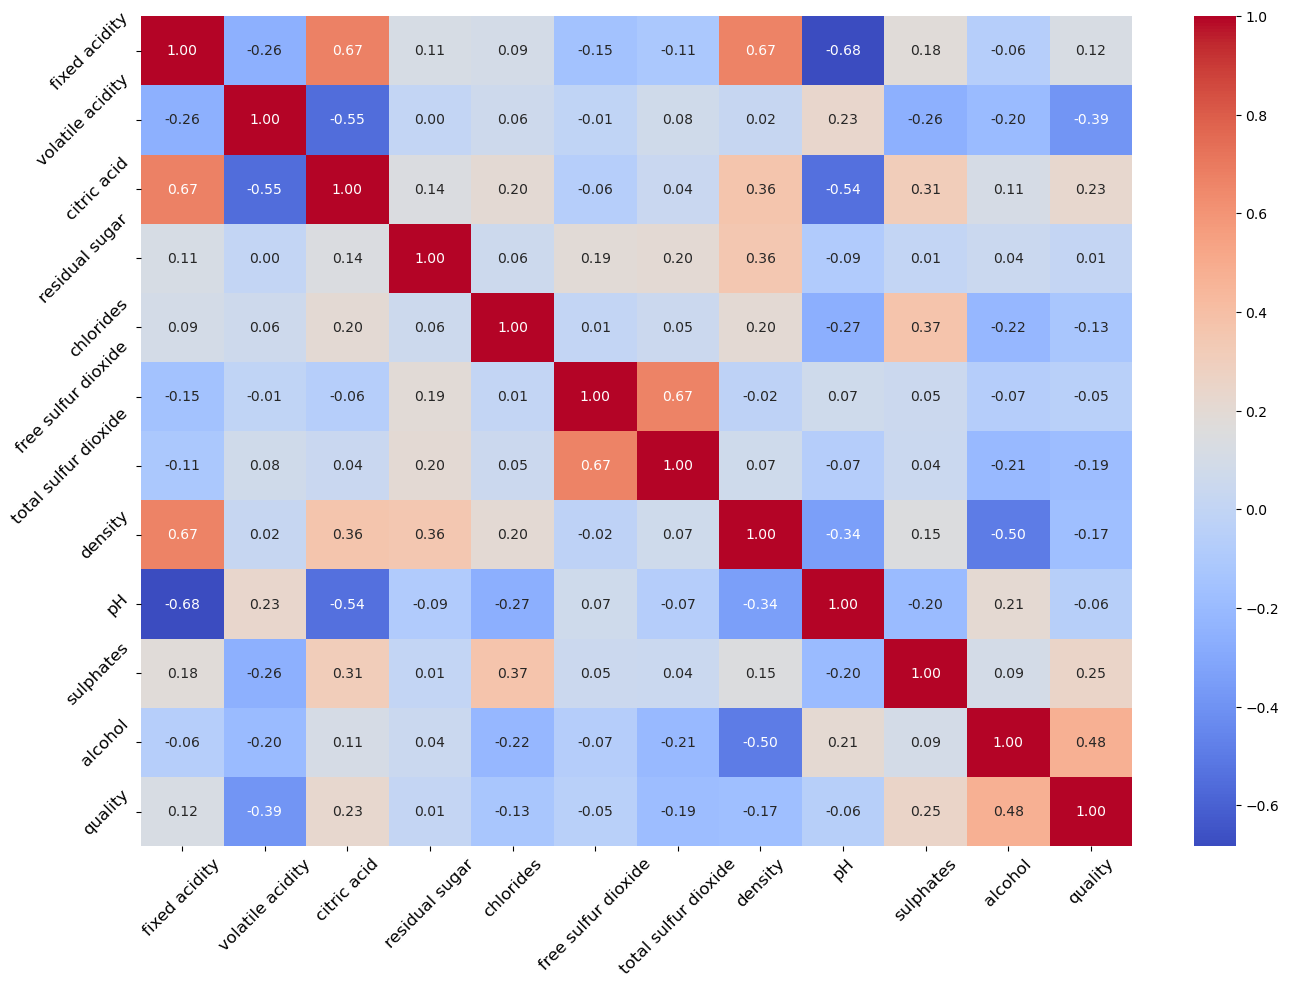

In [11]:
# 9. Display correlation matrix (Visuals)
plt.figure(figsize=(14, 10))
ax = sns.heatmap(data=df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
ax.tick_params(axis='both', rotation=45, labelsize=12)
plt.tight_layout()
plt.show()

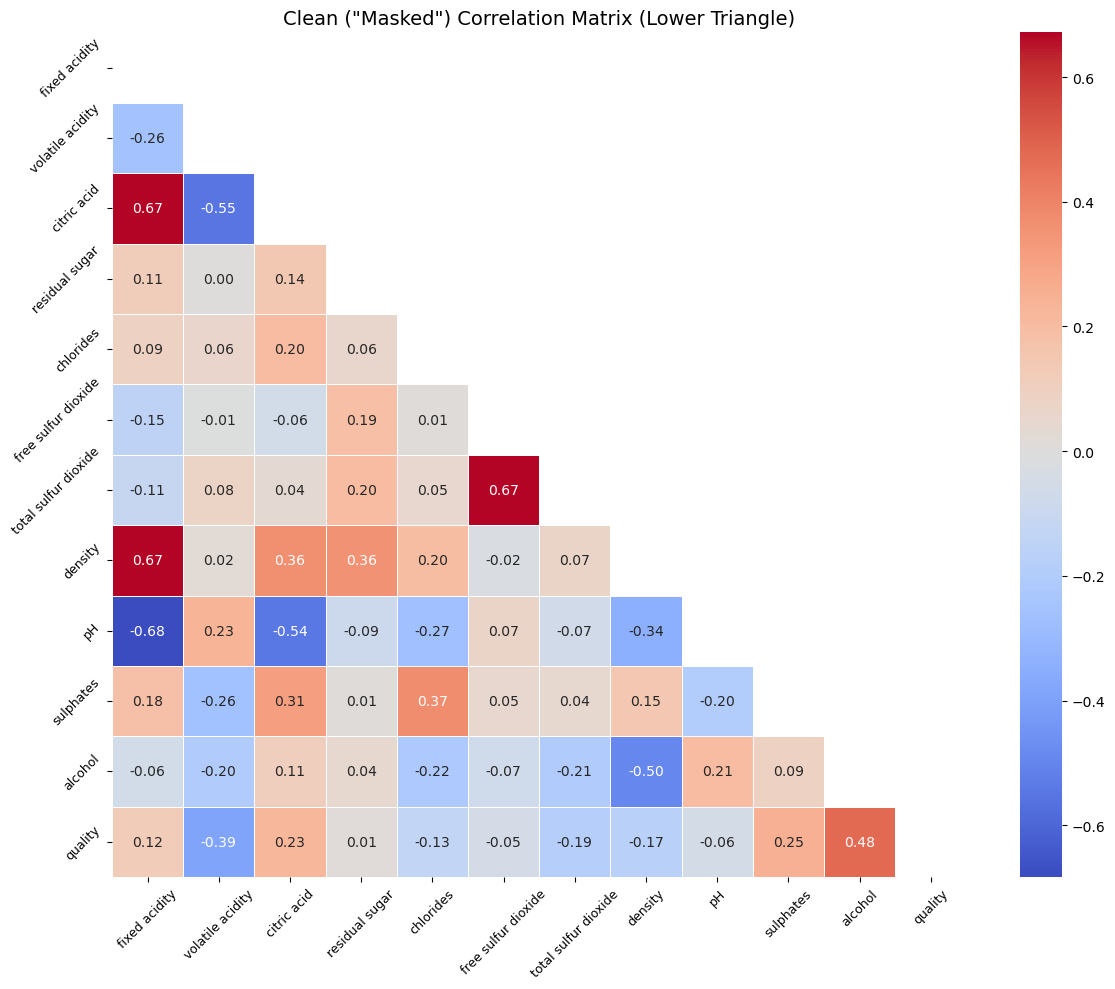

In [12]:
# 10. Masked ("triangular") Heatmap: make heatmap cleaner (apply mask to hide top-right triangle)
import numpy as np

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr,
    mask=mask,                 # 👈 hides upper triangle
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)

# Formatting
ax.tick_params(axis='both', rotation=45, labelsize=9)

plt.title('Clean ("Masked") Correlation Matrix (Lower Triangle)', fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
# 11. Create new col indicating "is good" based upon existing "quality" col
# Note use >=7 in "quality" col to determine good wine (creates NEW binary df col "is good")
# show new df with binary col (is_good) displays or 1!
df["is_good"] = (df["quality"] >= 7).astype(int)
df.style.format("{:.2f}")
df.round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_good
0,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.00,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.10,25.0,67.0,1.00,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.09,15.0,54.0,1.00,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.08,17.0,60.0,1.00,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.00,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.60,0.08,2.0,0.09,32.0,44.0,0.99,3.45,0.58,10.5,5,0
1595,5.9,0.55,0.10,2.2,0.06,39.0,51.0,1.00,3.52,0.76,11.2,6,0
1596,6.3,0.51,0.13,2.3,0.08,29.0,40.0,1.00,3.42,0.75,11.0,6,0
1597,5.9,0.64,0.12,2.0,0.08,32.0,44.0,1.00,3.57,0.71,10.2,5,0


In [14]:
# 12. Create and display independent variable (X) by returning NEW dataframe that removes "quality" and "is_good" cols from df
# display x
X = df.drop(columns=["quality", "is_good"])
X.round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.00,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.10,25.0,67.0,1.00,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.09,15.0,54.0,1.00,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.08,17.0,60.0,1.00,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.00,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.60,0.08,2.0,0.09,32.0,44.0,0.99,3.45,0.58,10.5
1595,5.9,0.55,0.10,2.2,0.06,39.0,51.0,1.00,3.52,0.76,11.2
1596,6.3,0.51,0.13,2.3,0.08,29.0,40.0,1.00,3.42,0.75,11.0
1597,5.9,0.64,0.12,2.0,0.08,32.0,44.0,1.00,3.57,0.71,10.2


In [15]:
y = df["is_good"]
y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: is_good, Length: 1599, dtype: int64

### Prepare model

In [16]:
# 14. Split data (80% train / 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# 15. Scale feature (IV) also known as Z score normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled = scaler.transform(X_test)         # transform only

In [18]:
#Display new X train scaled feature values
X_train_scaled

array([[ 0.21833164,  0.88971201,  0.19209222, ...,  1.09349989,
         0.45822284,  1.12317723],
       [-1.29016623, -1.78878251,  0.65275338, ..., -0.40043872,
        -0.40119696,  1.40827174],
       [ 1.49475291, -0.78434707,  1.01104539, ..., -0.07566946,
         0.51551749, -0.58738978],
       ...,
       [-0.65195559,  0.49909822, -1.08752211, ...,  1.28836145,
        -0.68767023, -0.87248428],
       [-0.24582155, -1.84458448,  0.39683051, ...,  0.05423824,
         0.80199076,  1.40827174],
       [-1.46422367, -1.34236676, -0.06383064, ...,  0.50891521,
        -0.68767023,  2.92877575]])

In [19]:
#17. Display new X test scaled feature values
X_test_scaled

array([[-3.61859850e-01,  1.64286407e-01, -9.85152962e-01, ...,
        -4.65392578e-01, -1.34389336e-04, -7.77452782e-01],
       [-3.03840702e-01, -1.70525408e-01, -5.24491803e-01, ...,
         5.08915214e-01, -1.03143815e+00, -8.72484283e-01],
       [ 1.37871461e+00,  7.78108067e-01, -2.68568937e-01, ...,
        -2.05577167e-01,  1.83329452e+00, -4.92358280e-01],
       ...,
       [-1.37449586e-02,  3.87494284e-01, -1.15015218e-01, ...,
        -1.04997725e+00, -7.44964886e-01, -5.87389780e-01],
       [ 2.76350785e-01, -1.45397070e+00,  6.01568807e-01, ...,
        -1.04997725e+00,  1.71749571e-01,  7.43051230e-01],
       [ 4.50408230e-01,  1.30822677e+00, -1.18989125e+00, ...,
        -1.40623314e-01, -6.87670232e-01, -6.82421281e-01]])

### Train and Assess

In [20]:
## 18. Train and evaluate/assess
# classification_report() provides detailed performance metrics:
# Precision: proportion of correct positive predictions
# Recall: proportion of actual positives correctly identified
# F1-score: harmonic mean of precision and recall
# Support: number of actual occurrences of each class

# Accuracy: overall correctness of the model
# Macro avg: average of metrics treating all classes equally
# Weighted avg: average weighted by number of samples per class
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# a. create model, fit model, create predictions
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

# b. print accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

# c. print classification report
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 90.00%

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       273
           1       0.73      0.51      0.60        47

    accuracy                           0.90       320
   macro avg       0.82      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



### Plot data

In [21]:
# extract feature importances
importances = model.feature_importances_

# create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# sort descending (most important first)
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# display
feature_importance.round(2)

,Feature,Importance
10,alcohol,0.17
9,sulphates,0.12
1,volatile acidity,0.11
7,density,0.09
2,citric acid,0.09
6,total sulfur dioxide,0.09
4,chlorides,0.08
0,fixed acidity,0.07
3,residual sugar,0.07
8,pH,0.06


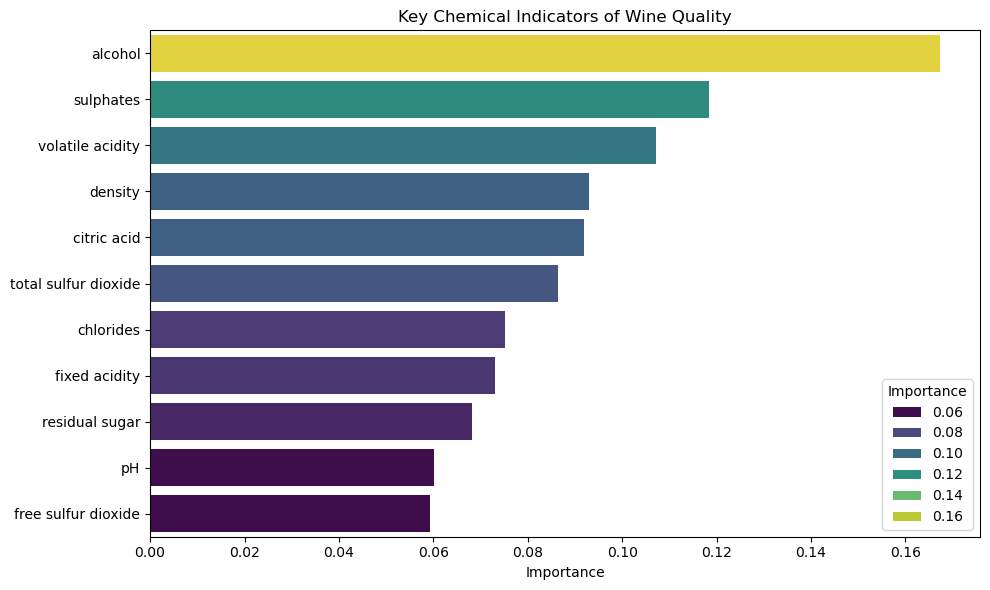

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Importance", 
    palette="viridis",
    dodge=False,
    legend=True
)

plt.title("Key Chemical Indicators of Wine Quality")
plt.xlabel("Importance")
plt.ylabel("")

plt.tight_layout()
plt.show()